`MeanPool` in a Support Vector Classification learnt on top of tile-level MoCo V2 features averaged over the slides.

In [1]:
!pip install tqdm
!pip install scikit-learn

In [2]:
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold

## Data loading

In [3]:
# put your own path to the data root directory (see example in `Data architecture` section)
data_dir = Path("/Users/enfants/Code/OWKIN_ML2")

# load the training and testing data sets
train_features_dir = data_dir / "train_input" / "moco_features"
test_features_dir = data_dir / "test_input" / "moco_features"
df_train = pd.read_csv(data_dir  / "supplementary_data" / "train_metadata.csv")
df_test = pd.read_csv(data_dir  / "supplementary_data" / "test_metadata.csv")

# concatenate y_train and df_train
y_train = pd.read_csv(data_dir  / "train_output.csv")
df_train = df_train.merge(y_train, on="Sample ID")

print(f"Training data dimensions: {df_train.shape}")  # (344, 4)
df_train.head()

Training data dimensions: (344, 4)


,Sample ID,Patient ID,Center ID,Target
0,ID_001.npy,P_001,C_1,0
1,ID_002.npy,P_002,C_2,1
2,ID_005.npy,P_005,C_5,0
3,ID_006.npy,P_006,C_5,0
4,ID_007.npy,P_007,C_2,1


## Data processing

We now load the features matrices $\mathbf{K_s} \in \mathbb{R}^{(1000,\,2048)}$ for $s=1,...,344$ and perform slide-level averaging. This operation should take at most 5 minutes on your laptop.

In [4]:
X_train = []
y_train = []
centers_train = []
patients_train = []

for sample, label, center, patient in tqdm(
    df_train[["Sample ID", "Target", "Center ID", "Patient ID"]].values
):
    # load the coordinates and features (1000, 3+2048)
    _features = np.load(train_features_dir / sample)
    # get coordinates (zoom level, tile x-coord on the slide, tile y-coord on the slide)
    # and the MoCo V2 features
    coordinates, features = _features[:, :3], _features[:, 3:]  # Ks
    # slide-level averaging
    X_train.append(np.mean(features, axis=0))
    y_train.append(label)
    centers_train.append(center)
    patients_train.append(patient)

# convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
centers_train = np.array(centers_train)
patients_train = np.array(patients_train)

  0%| | 0/344 [00:00<?, ?i

  9%| | 32/344 [00:00<00:0

 19%|▏| 64/344 [00:00<00:0

 28%|▎| 96/344 [00:00<00:0

 38%|▍| 130/344 [00:00<00:

...

 67%|▋| 231/344 [00:00<00:

 77%|▊| 264/344 [00:00<00:

 87%|▊| 298/344 [00:01<00:

 97%|▉| 332/344 [00:01<00:

100%|█| 344/344 [00:01<00:

## 5-fold cross validation

In [5]:
# /!\ we perform splits at the patient level so that all samples from the same patient
# are found in the same split

patients_unique = np.unique(patients_train)
y_unique = np.array(
    [np.mean(y_train[patients_train == p]) for p in patients_unique]
)
centers_unique = np.array(
    [centers_train[patients_train == p][0] for p in patients_unique]
)

print(
    "Training set specifications\n"
    "---------------------------\n"
    f"{len(X_train)} unique samples\n"
    f"{len(patients_unique)} unique patients\n"
    f"{len(np.unique(centers_unique))} unique centers"
)

Training set specifications
---------------------------
344 unique samples
305 unique patients
3 unique centers


In [6]:
aucs = []
svcs = []
# 5-fold CV is repeated 5 times with different random states
for k in range(5):
    kfold = StratifiedKFold(5, shuffle=True, random_state=k)
    fold = 0
    # split is performed at the patient-level
    for train_idx_, val_idx_ in kfold.split(patients_unique, y_unique):
        # retrieve the indexes of the samples corresponding to the
        # patients in `train_idx_` and `test_idx_`
        train_idx = np.arange(len(X_train))[
            pd.Series(patients_train).isin(patients_unique[train_idx_])
        ]
        val_idx = np.arange(len(X_train))[
            pd.Series(patients_train).isin(patients_unique[val_idx_])
        ]
        # set the training and validation folds
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]
        # instantiate the model
        svc = SVC(C=0.01, kernel="linear", probability=True)
        # fit it
        svc.fit(X_fold_train, y_fold_train)
        # get the predictions (1-d probability)
        preds_val = svc.predict_proba(X_fold_val)[:, 1]
        # compute the AUC score using scikit-learn
        auc = roc_auc_score(y_fold_val, preds_val)
        print(f"AUC on split {k} fold {fold}: {auc:.3f}")
        aucs.append(auc)
        # add the logistic regression to the list of classifiers
        svcs.append(svc)
        fold += 1
    print("----------------------------")
print(
    f"5-fold cross-validated AUC averaged over {k+1} repeats: "
    f"{np.mean(aucs):.3f} ({np.std(aucs):.3f})"
)

AUC on split 0 fold 0: 0.595


AUC on split 0 fold 1: 0.612


AUC on split 0 fold 2: 0.679


AUC on split 0 fold 3: 0.723
AUC on split 0 fold 4: 0.601
----------------------------


AUC on split 1 fold 0: 0.642


...

AUC on split 3 fold 0: 0.739
AUC on split 3 fold 1: 0.580


AUC on split 3 fold 2: 0.655


AUC on split 3 fold 3: 0.535
AUC on split 3 fold 4: 0.586
----------------------------


AUC on split 4 fold 0: 0.619
AUC on split 4 fold 1: 0.680


AUC on split 4 fold 2: 0.698
AUC on split 4 fold 3: 0.615
AUC on split 4 fold 4: 0.614
----------------------------
5-fold cross-validated AUC averaged over 5 repeats: 0.630 (0.063)


# Submission

Now we evaluate the previous models trained through cross-validation so that to produce a submission file that can directly be uploaded on the data challenge platform.

## Data processing

In [7]:
X_test = []

# load the data from `df_test` (~ 1 minute)
for sample in tqdm(df_test["Sample ID"].values):
    _features = np.load(test_features_dir / sample)
    coordinates, features = _features[:, :3], _features[:, 3:]
    X_test.append(np.mean(features, axis=0))

X_test = np.array(X_test)

  0%| | 0/149 [00:00<?, 

 21%|▏| 32/149 [00:00<00

 44%|▍| 65/149 [00:00<00

 66%|▋| 98/149 [00:00<00

 88%|▉| 131/149 [00:00<0

100%|█| 149/149 [00:00<0

## Inference

In [8]:
preds_test = 0
# loop over the classifiers
for svc in svcs:
    preds_test += svc.predict_proba(X_test)[:, 1]
# and take the average (ensembling technique)
preds_test = preds_test / len(svcs)

## Saving predictions

In [9]:
submission = pd.DataFrame(
    {"Sample ID": df_test["Sample ID"].values, "Target": preds_test}
).sort_values(
    "Sample ID"
)  # extra step to sort the sample IDs

# sanity checks
assert all(submission["Target"].between(0, 1)), "`Target` values must be in [0, 1]"
assert submission.shape == (149, 2), "Your submission file must be of shape (149, 2)"
assert list(submission.columns) == [
    "Sample ID",
    "Target",
], "Your submission file must have columns `Sample ID` and `Target`"

# save the submission as a csv file
submission.to_csv(data_dir / "SVC_test_output.csv", index=None)
submission.head()

,Sample ID,Target
0,ID_003.npy,0.494132
1,ID_004.npy,0.395800
2,ID_008.npy,0.336918
3,ID_009.npy,0.301209
4,ID_010.npy,0.317212


# Dealing with images

The following code aims to load and manipulate the images provided as part of  this challenge.

## Scanning images paths on disk

This operation can take up to 5 minutes.

In [10]:
train_images_dir = data_dir / "train_input" / "images"
train_images_files = list(train_images_dir.rglob("*.jpg"))

test_images_dir = data_dir / "test_input" / "images"
test_images_files = list(test_images_dir.rglob("*.jpg"))

print(
    f"Number of images\n"
    "-----------------\n"
    f"Train: {len(train_images_files)}\n" # 344 x 1000 = 344,000 tiles
    f"Test: {len(test_images_files)}\n"  # 149 x 1000 = 149,000 tiles
    f"Total: {len(train_images_files) + len(test_images_files)}\n"  # 493 x 1000 = 493,000 tiles
)

Number of images
-----------------
Train: 344000
Test: 149000
Total: 493000



## Reading

Now we can load some of the `.jpg` images for a given sample, say `ID_001`.

In [11]:
ID_001_tiles = [p for p in train_images_files if 'ID_001' in p.name]

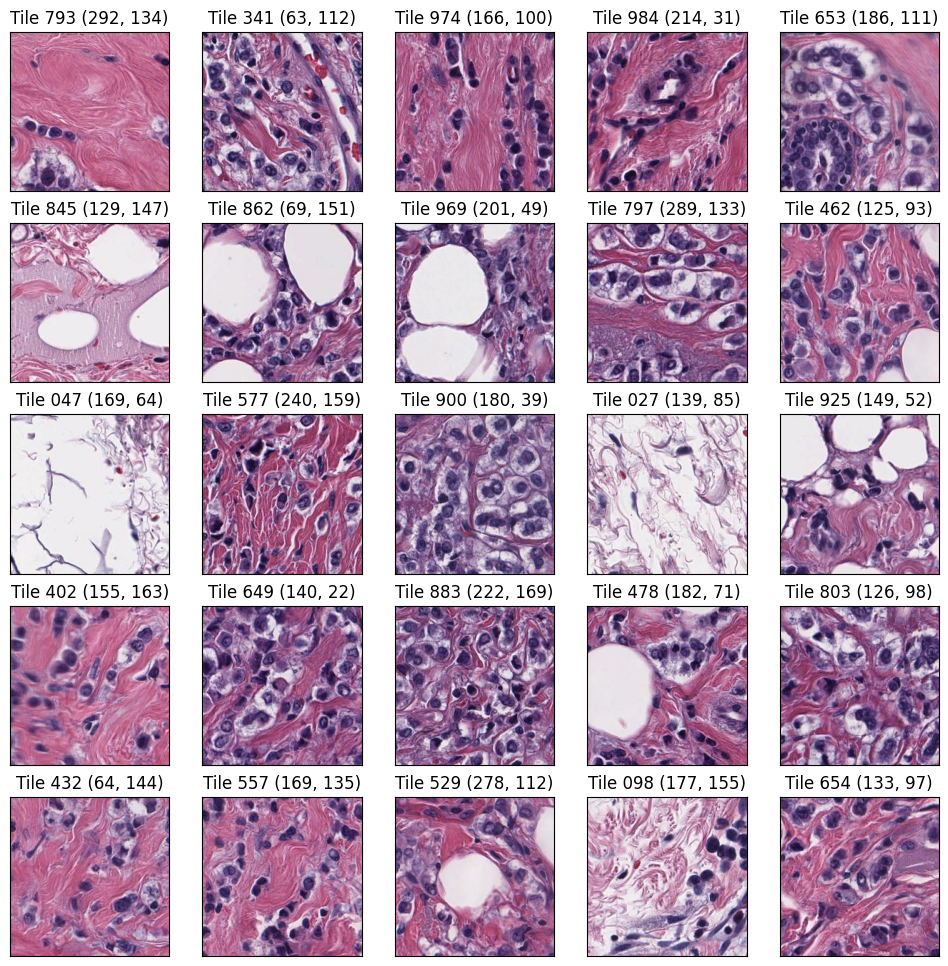

In [12]:
fig, axes = plt.subplots(5, 5)
fig.set_size_inches(12, 12)

for i, img_file in enumerate(ID_001_tiles[:25]):
    # get the metadata from the file path
    _, metadata = str(img_file).split("tile_")
    id_tile, level, x, y = metadata[:-4].split("_")
    img = plt.imread(img_file)
    ax = axes[i//5, i%5]
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Tile {id_tile} ({x}, {y})")
plt.show()

## Mapping with features

Note that the coordinates in the features matrices and tiles number are aligned.

In [13]:
sample = "ID_001.npy"
_features = np.load(train_features_dir / sample)
coordinates, features = _features[:, :3], _features[:, 3:]
print("xy features coordinates")
coordinates[:10, 1:].astype(int)

xy features coordinates


array([[170,  43],
       [245,  49],
       [137, 128],
       [218,  40],
       [142, 117],
       [129,  72],
       [129,  88],
       [164, 109],
       [210,  39],
       [222, 100]])

In [14]:
print(
    "Tiles numbering and features coordinates\n"
)
[tile.name for tile in ID_001_tiles[:10]]

Tiles numbering and features coordinates



['ID_001_tile_793_17_292_134.jpg',
 'ID_001_tile_341_17_63_112.jpg',
 'ID_001_tile_974_17_166_100.jpg',
 'ID_001_tile_984_17_214_31.jpg',
 'ID_001_tile_653_17_186_111.jpg',
 'ID_001_tile_845_17_129_147.jpg',
 'ID_001_tile_862_17_69_151.jpg',
 'ID_001_tile_969_17_201_49.jpg',
 'ID_001_tile_797_17_289_133.jpg',
 'ID_001_tile_462_17_125_93.jpg']

In [15]:
# ==========================================
# 1. Create Patient-Level Features
# ==========================================
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

print("Computing out-of-fold tile predictions...")

# We need to compute prediction on ALL tiles of the validation set during CV
oof_tile_preds = []
oof_tile_patients = []
oof_tile_targets = []

for k in range(5):
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=k)
    # We use svcs[k*5 : (k+1)*5] trained in the previous loops, but here we just retrain for simplicity 
    # to extract OOF tile predictions directly
    # To save time, we'll do just ONE 5-fold split to generate our OOF dataframe
    break

# Re-run ONE 5-fold CV to get OOF tile predictions
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx_, val_idx_ in kfold.split(patients_unique, y_unique):
    train_idx = np.arange(len(X_train))[pd.Series(patients_train).isin(patients_unique[train_idx_])]
    val_idx   = np.arange(len(X_train))[pd.Series(patients_train).isin(patients_unique[val_idx_])]
    
    # Train set (slide-level)
    X_fold_train = X_train[train_idx]
    y_fold_train = y_train[train_idx]
    
    # Train slide-level SVC
    svc = SVC(C=0.01, kernel="linear", probability=True)
    svc.fit(X_fold_train, y_fold_train)
    
    # Validation set (TILE-LEVEL)
    val_patients = patients_train[val_idx]
    val_targets  = y_train[val_idx]
    val_samples  = df_train["Sample ID"].values[val_idx]
    
    for sample, label, patient in zip(val_samples, val_targets, val_patients):
        # load raw tiles
        _features = np.load(train_features_dir / sample)
        features = _features[:, 3:]
        
        # predict on all tiles
        preds = svc.predict_proba(features)[:, 1]
        
        oof_tile_preds.extend(preds)
        oof_tile_patients.extend([patient] * len(preds))
        oof_tile_targets.extend([label] * len(preds))

df_oof_tiles = pd.DataFrame({
    "Patient ID": oof_tile_patients,
    "Target": oof_tile_targets,
    "Prediction": oof_tile_preds
})

print("Aggregating patient-level features...")
df_patient_features = df_oof_tiles.groupby("Patient ID").agg(
    Target=("Target", "first"),
    mean_prob=("Prediction", "mean"),
    max_prob=("Prediction", "max"),
    top20_prob=("Prediction", lambda x: np.percentile(x, 80)),
    top30_prob=("Prediction", lambda x: np.percentile(x, 70)),
    p90_prob=("Prediction", lambda x: np.percentile(x, 90)),
    p95_prob=("Prediction", lambda x: np.percentile(x, 95))
).reset_index()

print("Patient-level features generated. Shape:", df_patient_features.shape)
df_patient_features.head()


Computing out-of-fold tile predictions...


Aggregating patient-level features...
Patient-level features generated. Shape: (305, 8)


,Patient ID,Target,mean_prob,max_prob,top20_prob,top30_prob,p90_prob,p95_prob
0,P_001,0,0.367967,0.734677,0.442623,0.408823,0.500000,0.536100
1,P_002,1,0.394560,0.717332,0.464189,0.436344,0.500000,0.541221
2,P_005,0,0.340809,0.822780,0.449830,0.390762,0.539796,0.615504
3,P_006,0,0.344956,0.772211,0.467272,0.411365,0.544373,0.621921
4,P_007,1,0.461381,0.846031,0.571813,0.531616,0.620853,0.674788


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:42:37] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:42:37] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:42:37] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:42:37] WARNING: /Users/runner/miniforge3/conda-bld/x

Model Comparison: 5-Fold CV AUC
----------------------------------------
              Model  Mean AUC  Std AUC
Logistic Regression  0.631783 0.033206
            XGBoost  0.601885 0.052095


<Figure size 1000x600 with 0 Axes>

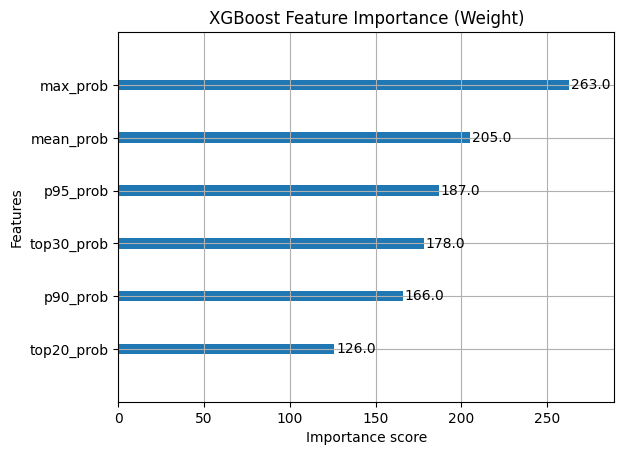

In [16]:
# ==========================================
# 2. StratifiedKFold CV at patient level
# 3. LogisticRegression baseline
# 4. XGBoost model
# 5. Compare models
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, plot_importance
import matplotlib.pyplot as plt

# Feature columns
feature_cols = ["mean_prob", "max_prob", "top20_prob", "top30_prob", "p90_prob", "p95_prob"]
X_pat = df_patient_features[feature_cols].values
y_pat = df_patient_features["Target"].values

lr_aucs = []
xgb_aucs = []

# 5-fold Stratified CV
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kfold.split(X_pat, y_pat):
    X_train_fold, X_val_fold = X_pat[train_idx], X_pat[val_idx]
    y_train_fold, y_val_fold = y_pat[train_idx], y_pat[val_idx]
    
    # --- Logistic Regression Baseline ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_val_scaled = scaler.transform(X_val_fold)
    
    lr = LogisticRegression()
    lr.fit(X_train_scaled, y_train_fold)
    lr_preds = lr.predict_proba(X_val_scaled)[:, 1]
    lr_aucs.append(roc_auc_score(y_val_fold, lr_preds))
    
    # --- XGBoost Model ---
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb.fit(X_train_fold, y_train_fold)
    xgb_preds = xgb.predict_proba(X_val_fold)[:, 1]
    xgb_aucs.append(roc_auc_score(y_val_fold, xgb_preds))

# Print Comparison Table
print("=" * 40)
print("Model Comparison: 5-Fold CV AUC")
print("-" * 40)
df_results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Mean AUC": [np.mean(lr_aucs), np.mean(xgb_aucs)],
    "Std AUC": [np.std(lr_aucs), np.std(xgb_aucs)]
})
print(df_results.to_string(index=False))
print("=" * 40)

# ==========================================
# 6. Feature importance (XGBoost)
# ==========================================
# Train XGBoost on all data to get overall importances
xgb_full = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# We pass the feature names explicitly so they appear on the plot
df_X = pd.DataFrame(X_pat, columns=feature_cols)
xgb_full.fit(df_X, y_pat)

plt.figure(figsize=(10, 6))
# plot_importance automatically plots the F score (weight) of features
plot_importance(xgb_full, importance_type='weight', title='XGBoost Feature Importance (Weight)', show_values=True)
plt.show()

# You can also plot other types: gain or cover
# plot_importance(xgb_full, importance_type='gain', title='XGBoost Feature Importance (Gain)')
# plt.show()
